### Iteration - 7 (QuantileTransformer)

In [0]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import silhouette_score, silhouette_samples


df_user_behavior = spark.table('workspace.spotify.spotify_user_behavior').toPandas()

CLUSTER_FEATURES_V7 = [
    'daily_listening_minutes',  # usage intensity
    'sessions_per_day',         # frequency
    'days_active_last_30',      # consistency
    'avg_session_minutes',      # depth
    'skip_rate',                # content friction
    'liked_songs_pct',          # positive engagement
    'ads_skipped_pct'           # monetization friction
]

In [0]:
base = df_user_behavior[['user_id'] + CLUSTER_FEATURES_V7].copy()
before_rows = len(base)
base = base.dropna(subset = CLUSTER_FEATURES_V7)
after_rows = len(base)

if before_rows != after_rows:
    print(f' Dropped {before_rows - after_rows} rows due to nulls')

In [0]:
k =4 # 3-4 clusters are consider for business personas

In [0]:
X7= base[CLUSTER_FEATURES_V7].copy()

qt = QuantileTransformer(
    n_quantiles = 10,
    output_distribution = 'normal',
    ignore_implicit_zeros = True,
    random_state = 42
    
)

X7_scaled = qt.fit_transform(X7)
X7 = pd.DataFrame(
    X7_scaled,
    columns = CLUSTER_FEATURES_V7,
    index = base.index
)

km7= KMeans(
    n_clusters = k,
    random_state = 42,
    n_init = 20,   # more stable than sklearn default (often 10)
    max_iter = 300
)

/databricks/python/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:2732: UserWarning: 'ignore_implicit_zeros' takes effect only with sparse matrix. This parameter has no effect.
  warnings.warn(


In [0]:
labels7 = km7.fit_predict(X7)
inertia7 = km7.inertia_

sil_avg_7= silhouette_score(X7, labels7)
base_iter7 = base.copy()
base_iter7['cluster']= labels7
print(f'Inertia: {round(inertia7,2)}')
print(f' Silhoutte: {round(sil_avg_7,2)}')
sizes7 = base_iter7['cluster'].value_counts().sort_index()
sizes7

Inertia: 470674.14
 Silhoutte: 0.28


cluster
0    41033
1    41317
2    20403
3     5247
Name: count, dtype: int64

In [0]:
means7= (
    base_iter7.groupby('cluster')[CLUSTER_FEATURES_V7].mean().round(3))

In [0]:
profile7 = means7.copy()
profile7.insert(0, 'cluster_size', sizes7)
display(profile7)

cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
41033,16.5531930793524,1.0,19.973203466798445,16.5531930793524,0.39,0.25513937311096513,0.48410352975887927
41317,50.021560233954155,1.0,20.97324349620811,50.021560233954155,0.272,0.3058464417305656,0.5950813168828087
20403,77.68456173943838,2.63,21.714096469795834,29.20287803362299,0.305,0.29823237098076677,0.5673281092669187
5247,40.44013871948896,1.0,29.998780904640363,40.44013871948896,0.327,0.3275244180890622,0.5154526008286368


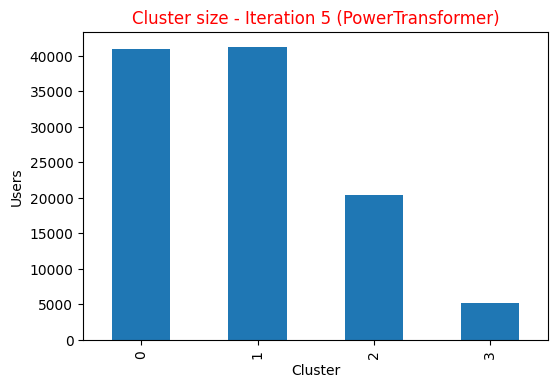

In [0]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,4))

base_iter7['cluster'].value_counts().sort_index().plot(kind= 'bar')
plt.title('Cluster size - Iteration 5 (PowerTransformer)', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Users')
plt.show()

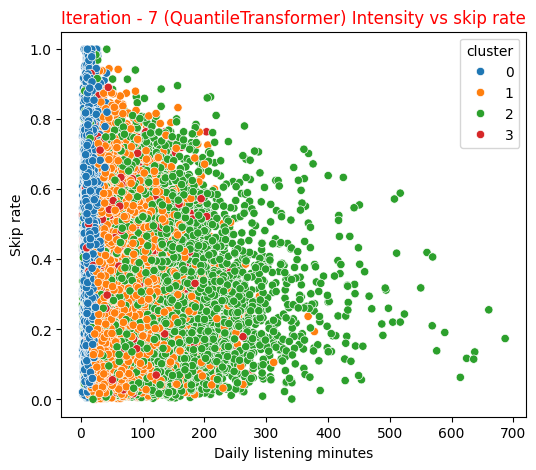

In [0]:
# scatter plot (No PCA)

# intensity vs skip
import seaborn as sns

plt.figure(figsize= (6,5))
sns.scatterplot(
    data = base_iter7,
    x = 'daily_listening_minutes',
    y = 'skip_rate',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 7 (QuantileTransformer) Intensity vs skip rate', color = 'red')
plt.xlabel('Daily listening minutes')
plt.ylabel('Skip rate')
plt.show()

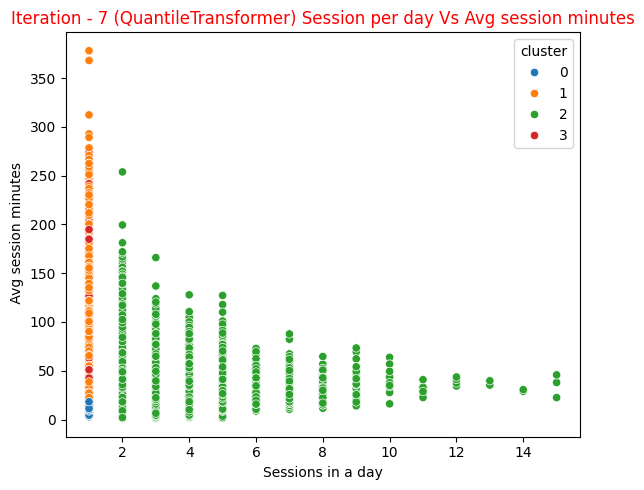

In [0]:
# frequency vs Session depth

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter7,
    x = 'sessions_per_day',
    y= 'avg_session_minutes',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 7 (QuantileTransformer) Session per day Vs Avg session minutes', color = 'red')
plt.xlabel('Sessions in a day')
plt.ylabel(' Avg session minutes')
plt.tight_layout()
plt.show()

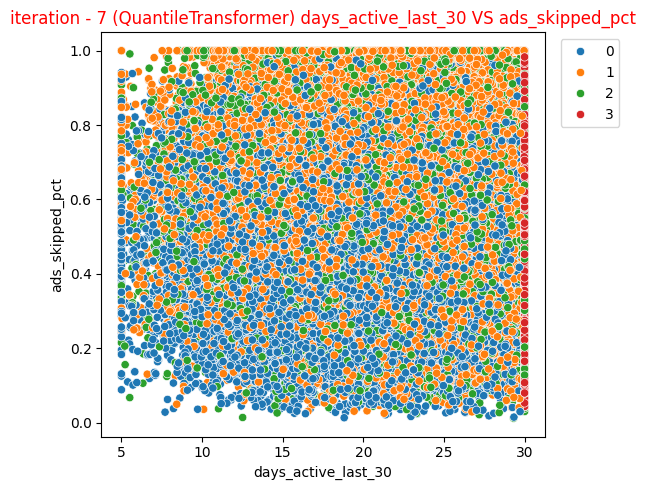

In [0]:
# consistance vs Ad friction

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter7,
    x = 'days_active_last_30',
    y= 'ads_skipped_pct',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('iteration - 7 (QuantileTransformer) days_active_last_30 VS ads_skipped_pct', color = 'red')
plt.legend(bbox_to_anchor = (1.02, 1))
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

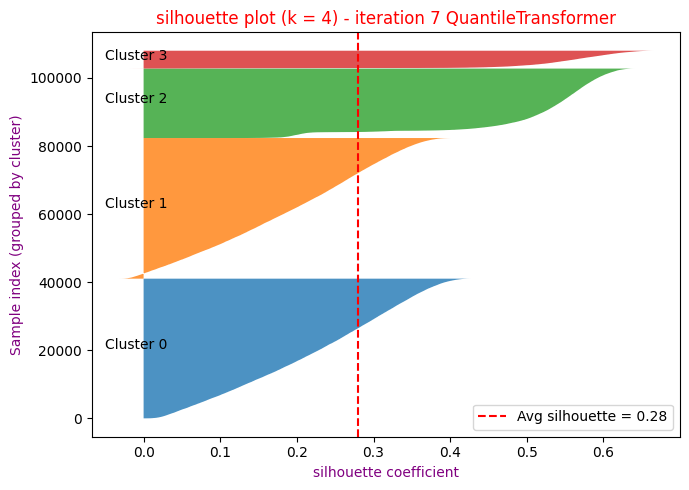

In [0]:
# silhouette Plot

sil_values_7 = silhouette_samples(X7, labels7)
sil_avg_7 = silhouette_score(X7, labels7)
plt.figure(figsize= (7,5))

y_lower = 0

vals0 = sil_values_7[labels7 == 0]
vals0.sort()
size0 = vals0.shape[0]

y_upper = y_lower + size0

plt.fill_betweenx(
    np.arange(y_lower, y_upper),    # vertical span
    0,                              # left boundary (silhoutte = 0)
    vals0,                          # right boundary (actual silhoutte values)
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5 * size0,  # slightly left of zero
    'Cluster 0'             # vertically centered
)

y_lower = y_upper

# Cluster 1
vals1 = sil_values_7[labels7==1]
vals1.sort()
size1 = vals1.shape[0]

y_upper = y_lower + size1

plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
    )
plt.text(-0.05,
         y_lower + 0.5 * size1, 'Cluster 1')

y_lower = y_upper

# cluster 2
vals2 = sil_values_7[labels7 == 2]
vals2.sort()

size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size2, 'Cluster 2')

y_lower = y_upper

# cluster 3
vals3 = sil_values_7[labels7 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size3, 'Cluster 3')

y_lower = y_upper

plt.axvline(
    x= sil_avg_7,
    color = 'red',
    linestyle = '--',
    label =f"Avg silhouette = {sil_avg_7:.2f}"
)

plt.title('silhouette plot (k = 4) - iteration 7 QuantileTransformer', color = 'red')
plt.xlabel('silhouette coefficient', color = 'purple')
plt.ylabel('Sample index (grouped by cluster)', color = 'purple')
plt.legend()
plt.tight_layout()
plt.show